In [1]:
import os
import pandas as pd
from transformers import AutoTokenizer
import json
import matplotlib.pyplot as plt
import statistics
import sys
import seaborn as sns
sys.path.append('..')
from style_setup import set_thesis_style
set_thesis_style()

## Check how much data is >2048 tokens

In [22]:
# Load the tokenizer for Llama
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

# Path to the jsonl file
#file_path = "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_all_Llama.jsonl"
#file_path = "../../Data/Finetuning/Augmented/Small/Other/dolly_train_all_multi.jsonl"
#file_path = "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_all_Llama.jsonl"
file_path = "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_all_multi.jsonl"

# Check if the file exists
if not os.path.exists(file_path):
    print(f"File not found: {file_path}")
else:
    # Count total entries and those exceeding token limit
    total_entries = 0
    exceeding_limit = 0
    max_tokens = 0
    total_instruction_tokens_exceeding = 0
    instruction_token_lengths = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            total_entries += 1
            data = json.loads(line)
            
            # Find the appropriate response key (not using response_human)
            response_key = next((key for key in data.keys() 
                               if key.startswith("response_") and key != "response_human"), 
                              "response")  # fallback to "response" if no matching key found
            
            # Tokenize instruction and combined text separately
            instruction_text = data['instruction']
            instruction_tokens = tokenizer.encode(instruction_text)
            instruction_token_count = len(instruction_tokens)
            
            combined_text = f"You are a helpful assistant.\nInstruction: {data['instruction']}\nResponse: {data[response_key]}"
            tokens = tokenizer.encode(combined_text)
            token_count = len(tokens)
            
            # Update max token count
            max_tokens = max(max_tokens, token_count)
            
            # Check if token count exceeds limit
            if token_count > 2048:
                exceeding_limit += 1
                total_instruction_tokens_exceeding += instruction_token_count
                instruction_token_lengths.append(instruction_token_count)
    
    # Calculate percentages and averages
    percentage = (exceeding_limit / total_entries) * 100 if total_entries > 0 else 0
    avg_instruction_tokens = total_instruction_tokens_exceeding / exceeding_limit if exceeding_limit > 0 else 0
    median_instruction_tokens = statistics.median(instruction_token_lengths) if instruction_token_lengths else 0
    
    print(f"Total entries: {total_entries}")
    print(f"Entries exceeding 2048 tokens: {exceeding_limit} ({percentage:.2f}%)")
    print(f"Maximum token count found: {max_tokens}")
    print(f"Average instruction length for entries exceeding limit: {avg_instruction_tokens:.2f} tokens")
    print(f"Median instruction length for entries exceeding limit: {median_instruction_tokens:.2f} tokens")


Total entries: 13509
Entries exceeding 2048 tokens: 30 (0.22%)
Maximum token count found: 6216
Average instruction length for entries exceeding limit: 2863.77 tokens
Median instruction length for entries exceeding limit: 2448.00 tokens


# Plot loss curves

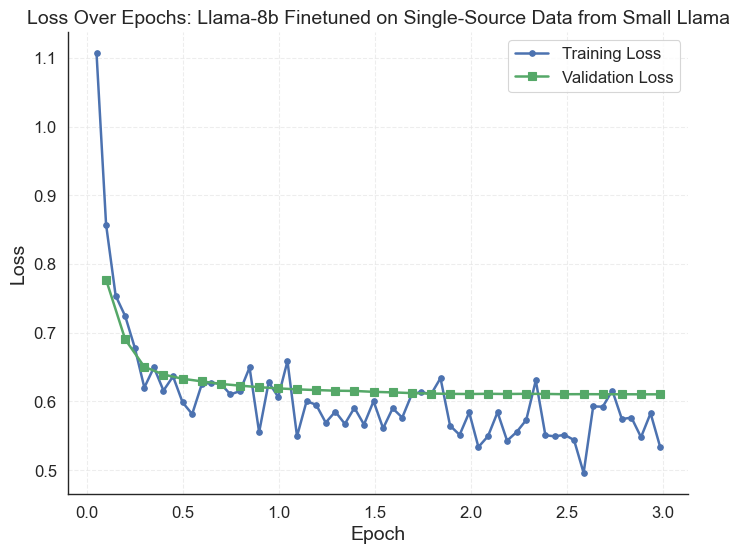

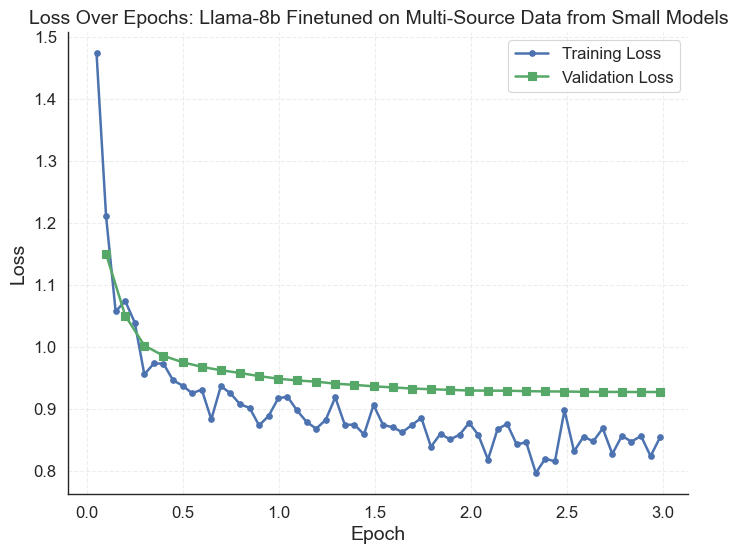

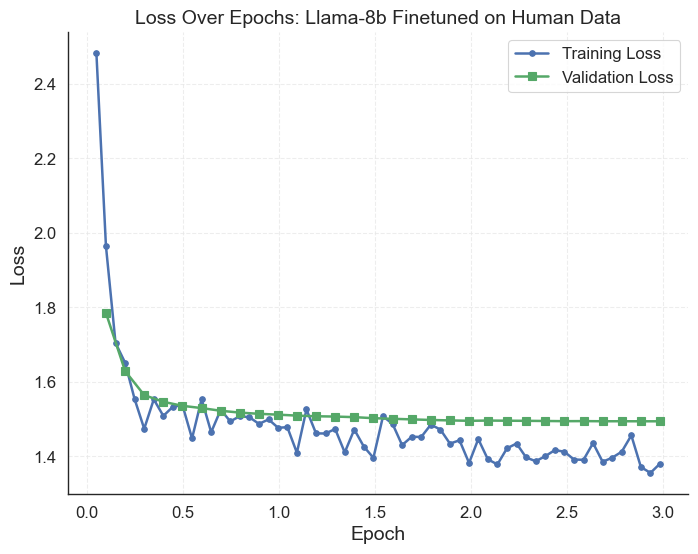

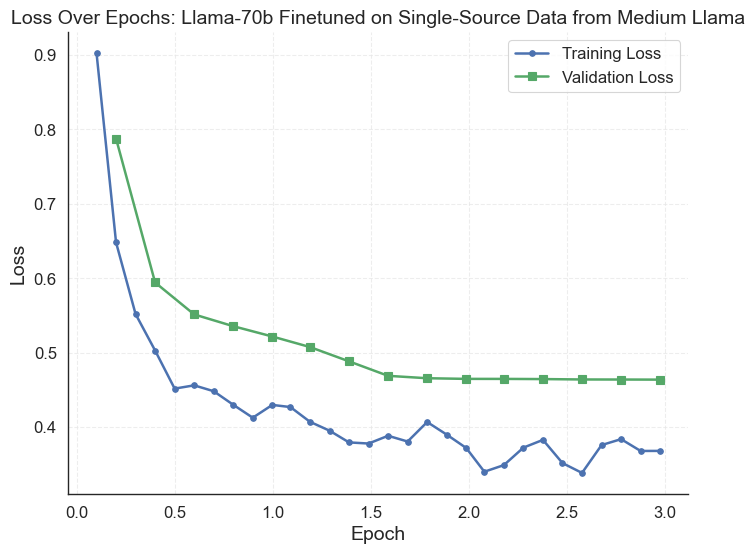

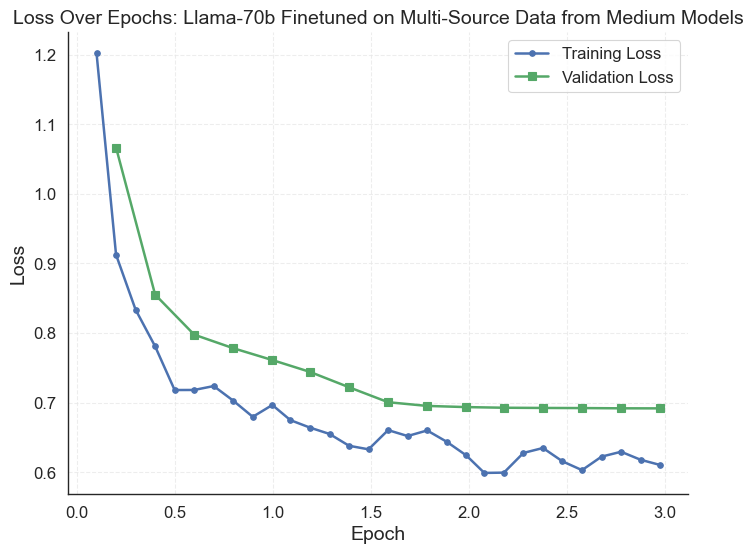

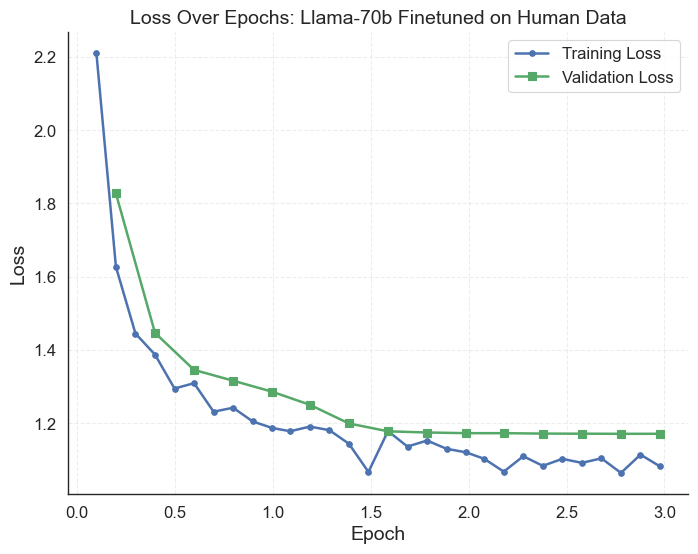

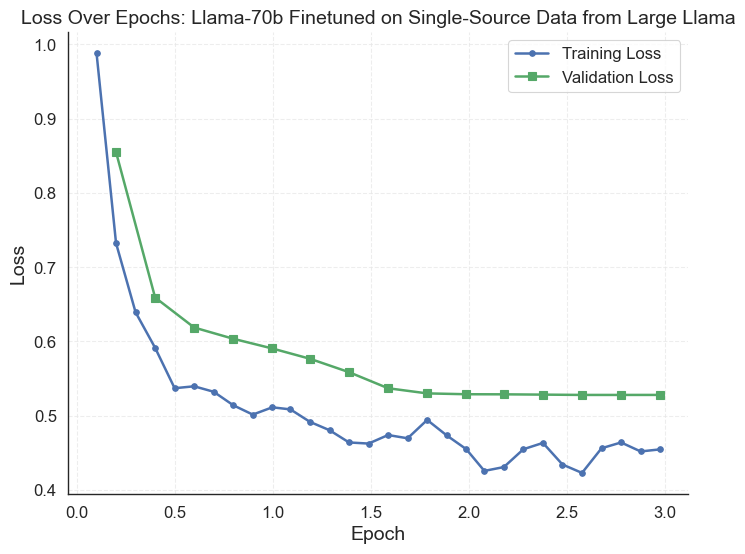

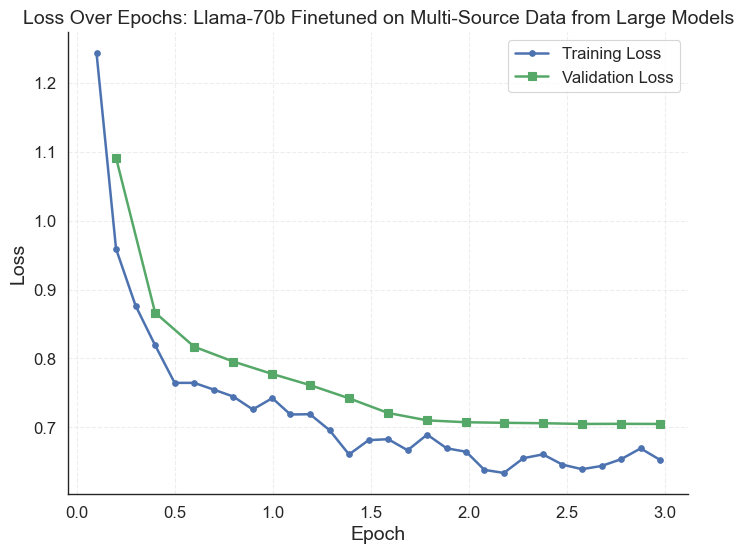

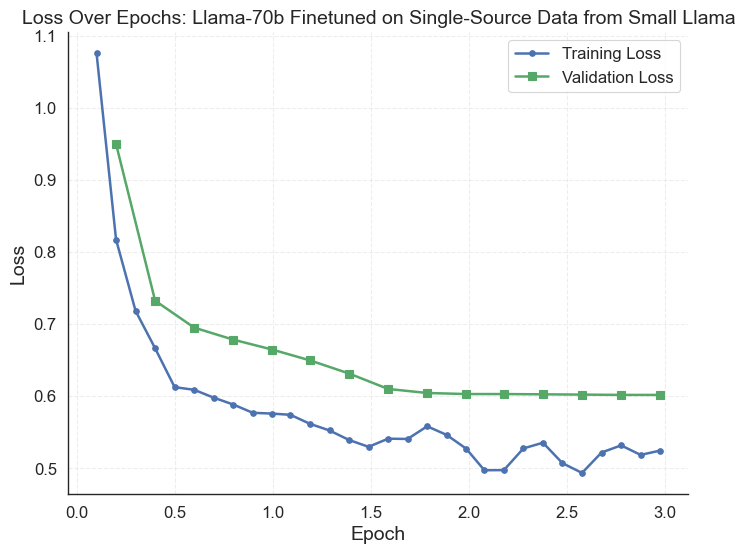

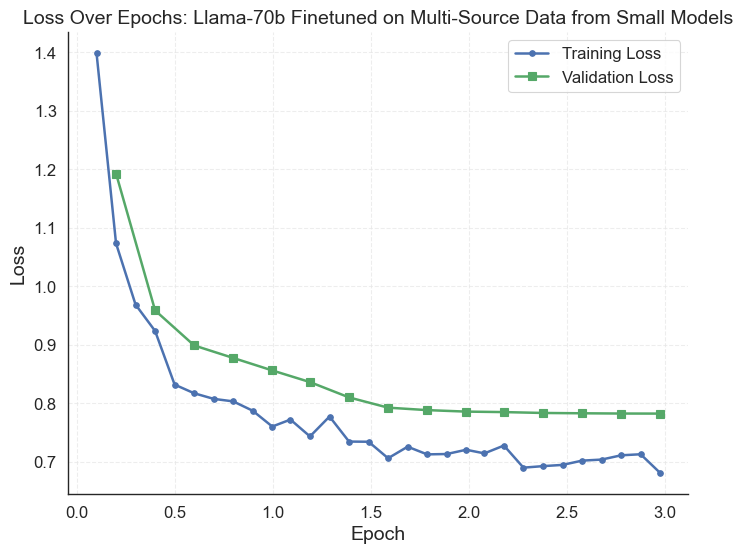

In [29]:
# Load the trainer state from the checkpoint
checkpoints_paths = {
    "8b_single_small": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/small/trainer_state_8b_single.json",
    "8b_multi_small": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/small/trainer_state_8b_multi.json",
    "8b_human_small": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/small/trainer_state_8b_human.json",
    "70b_single_medium": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_single_medium.json",
    "70b_multi_medium": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_multi_medium.json",
    "70b_human_medium": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_human_medium.json",
    "70b_single_large": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_single_large.json",
    "70b_multi_large": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_multi_large.json",
    "70b_single_small": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_single_small.json",
    "70b_multi_small": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_multi_small.json",
}

for checkpoint_name, checkpoint_path in checkpoints_paths.items():
    with open(checkpoint_path, 'r') as f:
        trainer_state = json.load(f)

    log_hist = trainer_state['log_history']

    # Create a DataFrame from the log history
    log_df = pd.DataFrame(log_hist)

    log_df.head(10)

    # Create a DataFrame from the log history
    log_df = pd.DataFrame(log_hist)

    # Plot both training and validation loss on the same figure
    plt.figure(figsize=(8, 6))

    # Filter out NaN values before plotting
    filtered_df_loss = log_df.dropna(subset=['loss'])
    filtered_df_eval_loss = log_df.dropna(subset=['eval_loss'])

    # Plot training loss
    plt.plot(filtered_df_loss['epoch'], filtered_df_loss['loss'], label='Training Loss', marker='o', markersize=4)

    # Plot validation loss
    plt.plot(filtered_df_eval_loss['epoch'], filtered_df_eval_loss['eval_loss'], label='Validation Loss', marker='s', markersize=6)

    # Set larger font sizes for all text elements
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    checkpoint_name_split = checkpoint_name.replace("_", " ").split()
    if checkpoint_name_split[1] == "single":
        title = f"Loss Over Epochs: Llama-{checkpoint_name_split[0]} Finetuned on {str.capitalize(checkpoint_name_split[1])}-Source Data from {str.capitalize(checkpoint_name_split[2])} Llama"
    elif checkpoint_name_split[1] != "human":
        title = f"Loss Over Epochs: Llama-{checkpoint_name_split[0]} Finetuned on {str.capitalize(checkpoint_name_split[1])}-Source Data from {str.capitalize(checkpoint_name_split[2])} Models"
    else:
        title = f"Loss Over Epochs: Llama-{checkpoint_name_split[0]} Finetuned on Human Data"

    plt.title(title, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(f'/Users/maxschaffelder/Desktop/Thesis/plots/finetuning/loss_{checkpoint_name}.png', dpi=300)
    plt.show()



### Find number of identical responses for single source to explain similar looking loss curves across generator model sizes

In [38]:
import json
from collections import Counter

# Paths to the files
large_file = "/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Llama/dolly_train_all_Llama.jsonl"
medium_file = "/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_train_all_Llama.jsonl"
small_file = "/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_train_all_Llama.jsonl"

# Function to load responses from a file
def load_responses(file_path):
    responses = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line.strip())
            responses.append(data.get('response_model', ''))
    return responses

# Load responses from all three files
large_responses = load_responses(large_file)
medium_responses = load_responses(medium_file)
small_responses = load_responses(small_file)

# Find identical responses across all three files
identical_responses = set(large_responses) & set(medium_responses) & set(small_responses)

print(f"Number of unique identical responses across all three files: {len(identical_responses)}")

# Count occurrences in each file
large_counter = Counter(large_responses)
medium_counter = Counter(medium_responses)
small_counter = Counter(small_responses)

# Count total identical entries (including duplicates)
total_identical_entries = 0
for response in identical_responses:
    # Count the minimum number of occurrences across all three files
    min_count = min(large_counter[response], medium_counter[response], small_counter[response])
    total_identical_entries += min_count

print(f"Total number of identical entries (including duplicates) across all three files: {total_identical_entries}")

# Find identical responses between pairs of files
print("\nFinding identical responses between pairs of files...")

# Small and Medium
small_medium_identical = set(small_responses) & set(medium_responses)
print(f"Number of unique identical responses between Small and Medium: {len(small_medium_identical)}")

# Small and Large
small_large_identical = set(small_responses) & set(large_responses)
print(f"Number of unique identical responses between Small and Large: {len(small_large_identical)}")

# Medium and Large
medium_large_identical = set(medium_responses) & set(large_responses)
print(f"Number of unique identical responses between Medium and Large: {len(medium_large_identical)}")



Number of unique identical responses across all three files: 146
Total number of identical entries (including duplicates) across all three files: 149

Finding identical responses between pairs of files...
Number of unique identical responses between Small and Medium: 289
Number of unique identical responses between Small and Large: 246
Number of unique identical responses between Medium and Large: 515


In [ ]:
# Load the trainer state from the checkpoint
checkpoints_paths = {
    "8b_single_small": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/small/trainer_state_8b_single.json",
    "8b_multi_small": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/small/trainer_state_8b_multi.json",
    "8b_human_small": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/small/trainer_state_8b_human.json",
    "70b_single_medium": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_single_medium.json",
    "70b_multi_medium": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_multi_medium.json",
    "70b_human_medium": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_human_medium.json",
    "70b_single_large": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_single_large.json",
    "70b_multi_large": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_multi_large.json",
    "70b_single_small": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_single_small.json",
    "70b_multi_small": "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/medium/trainer_state_70b_multi_small.json",
}

for checkpoint_name, checkpoint_path in checkpoints_paths.items():
    with open(checkpoint_path, 'r') as f:
        trainer_state = json.load(f)

    log_hist = trainer_state['log_history']

    # Create a DataFrame from the log history
    log_df = pd.DataFrame(log_hist)

    log_df.head(10)

    # Create a DataFrame from the log history
    log_df = pd.DataFrame(log_hist)

    # Plot both training and validation loss on the same figure
    plt.figure(figsize=(8, 6))

    # Filter out NaN values before plotting
    filtered_df_loss = log_df.dropna(subset=['loss'])
    filtered_df_eval_loss = log_df.dropna(subset=['eval_loss'])

    # Plot training loss
    plt.plot(filtered_df_loss['epoch'], filtered_df_loss['loss'], label='Training Loss', marker='o', markersize=4)

    # Plot validation loss
    plt.plot(filtered_df_eval_loss['epoch'], filtered_df_eval_loss['eval_loss'], label='Validation Loss', marker='s', markersize=6)

    # Set larger font sizes for all text elements
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    checkpoint_name_split = checkpoint_name.replace("_", " ").split()
    if checkpoint_name_split[1] == "single":
        title = f"Loss Over Epochs: Llama-{checkpoint_name_split[0]} Finetuned on {str.capitalize(checkpoint_name_split[1])}-Source Data from {str.capitalize(checkpoint_name_split[2])} Llama"
    elif checkpoint_name_split[1] != "human":
        title = f"Loss Over Epochs: Llama-{checkpoint_name_split[0]} Finetuned on {str.capitalize(checkpoint_name_split[1])}-Source Data from {str.capitalize(checkpoint_name_split[2])} Models"
    else:
        title = f"Loss Over Epochs: Llama-{checkpoint_name_split[0]} Finetuned on Human Data"

    plt.title(title, fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(f'/Users/maxschaffelder/Desktop/Thesis/plots/finetuning/loss_{checkpoint_name}.png', dpi=300)
    plt.show()


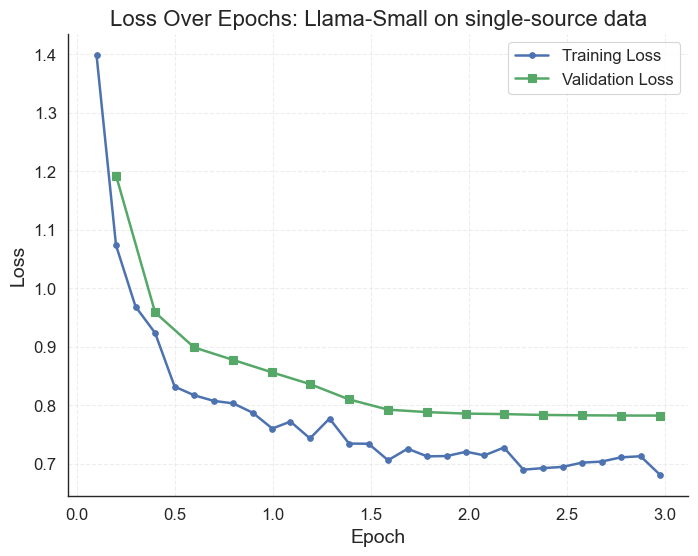

In [11]:
# Plot both training and validation loss on the same figure
plt.figure(figsize=(8, 6))

# Filter out NaN values before plotting
filtered_df_loss = log_df.dropna(subset=['loss'])
filtered_df_eval_loss = log_df.dropna(subset=['eval_loss'])

# Plot training loss
plt.plot(filtered_df_loss['epoch'], filtered_df_loss['loss'], label='Training Loss', marker='o', markersize=4)

# Plot validation loss
plt.plot(filtered_df_eval_loss['epoch'], filtered_df_eval_loss['eval_loss'], label='Validation Loss', marker='s', markersize=6)

# Set larger font sizes for all text elements
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
#plt.title('Loss Over Epochs: Llama-Small on human-source data', fontsize=16)
#plt.title('Loss Over Epochs: Llama-Small on multi-source data', fontsize=16)
plt.title('Loss Over Epochs: Llama-Small on single-source data', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
#plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/finetuning/loss_over_epochs_llama8b_multi_v3.png', dpi=300)
#plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/finetuning/loss_over_epochs_llama8b_single_v8.png', dpi=300)
plt.show()

In [45]:
def analyze_eval_loss_improvement(checkpoint_path, key_name):
    """
    Analyze evaluation loss improvement patterns for a given checkpoint file.
    
    Args:
        checkpoint_path (str): Path to the trainer_state JSON file
        key_name (str): Name/key for the model configuration
    """
    with open(checkpoint_path, 'r') as f:
        trainer_state = json.load(f)
        log_hist = trainer_state['log_history']
        log_df = pd.DataFrame(log_hist)

    # Get evaluation losses
    eval_losses = log_df.dropna(subset=['eval_loss'])[['step', 'epoch', 'eval_loss']]
    
    eval_losses_list = eval_losses['eval_loss'].tolist()
    steps_list = eval_losses['step'].tolist()

    consecutive_no_improvement = 0
    current_start_step = None
    found_periods = False

    print(f"\n=== Analysis for {key_name} ===")
    
    for i in range(1, len(eval_losses_list)):
        if eval_losses_list[i] >= eval_losses_list[i-1]:  # No improvement
            if consecutive_no_improvement == 0:
                current_start_step = steps_list[i-1]
            consecutive_no_improvement += 1
        else:  # Improvement
            if consecutive_no_improvement >= 5:
                print(f"Found {consecutive_no_improvement} consecutive steps without improvement starting at step {current_start_step}")
                print(f"  Loss values: {eval_losses_list[i-consecutive_no_improvement-1:i+1]}")
                found_periods = True
            consecutive_no_improvement = 0
            current_start_step = None

    # Check if the last sequence also meets the criteria
    if consecutive_no_improvement >= 5:
        print(f"Found {consecutive_no_improvement} consecutive steps without improvement starting at step {current_start_step}")
        print(f"  Loss values: {eval_losses_list[-consecutive_no_improvement-1:]}")
        found_periods = True

    if not found_periods:
        print(f"No periods found where eval loss didn't decrease for 5 or more consecutive steps.")

# Run analysis for all checkpoints
for key, path in checkpoints_paths.items():
    analyze_eval_loss_improvement(path, key)



=== Analysis for 8b_single_small ===
No periods found where eval loss didn't decrease for 5 or more consecutive steps.

=== Analysis for 8b_multi_small ===
No periods found where eval loss didn't decrease for 5 or more consecutive steps.

=== Analysis for 8b_human_small ===
No periods found where eval loss didn't decrease for 5 or more consecutive steps.

=== Analysis for 70b_single_medium ===
No periods found where eval loss didn't decrease for 5 or more consecutive steps.

=== Analysis for 70b_multi_medium ===
No periods found where eval loss didn't decrease for 5 or more consecutive steps.

=== Analysis for 70b_human_medium ===
No periods found where eval loss didn't decrease for 5 or more consecutive steps.

=== Analysis for 70b_single_large ===
No periods found where eval loss didn't decrease for 5 or more consecutive steps.

=== Analysis for 70b_multi_large ===
No periods found where eval loss didn't decrease for 5 or more consecutive steps.

=== Analysis for 70b_single_small ==